In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        break
    break

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import os
import matplotlib.pyplot as plt

## Download train, validation and test dataframes

In [3]:
train_id = "16ADiN0-geWlmkhN04bymFy_N7OA0SPHy"
train_url = f'https://drive.google.com/uc?id={train_id}'
# Load the CSV file into a pandas DataFrame
train_df = pd.read_csv(train_url)
train_df.head()

,File,Encoded_Label
0,n02437312/images/n02437312_229.JPEG,53
1,n02437312/images/n02437312_394.JPEG,53
2,n02437312/images/n02437312_15.JPEG,53
3,n02437312/images/n02437312_62.JPEG,53
4,n02437312/images/n02437312_17.JPEG,53


In [4]:
train_df["Encoded_Label"]

0         53
1         53
2         53
3         53
4         53
        ... 
99995    121
99996    121
99997    121
99998    121
99999    121
Name: Encoded_Label, Length: 100000, dtype: int64

In [5]:
val_id = "1lGkKcAD6Kc7JhfYsa9naVIwwc-MKdXQI"
val_url = f'https://drive.google.com/uc?id={val_id}'
# Load the CSV file into a pandas DataFrame
val_df = pd.read_csv(val_url)
val_df.head()

,File,Encoded_Label
0,val_4526.JPEG,115
1,val_7545.JPEG,88
2,val_1726.JPEG,149
3,val_4997.JPEG,99
4,val_6429.JPEG,149


In [6]:
test_id = "1lOi6xnfVghuzj1fYlIBbLNWWZQvahygQ"
test_url = f'https://drive.google.com/uc?id={test_id}'
# Load the CSV file into a pandas DataFrame
test_df = pd.read_csv(test_url)
test_df.head()

,File
0,val_9240.JPEG
1,val_9308.JPEG
2,val_3262.JPEG
3,val_3528.JPEG
4,val_4147.JPEG


In [7]:
class CSVImageDataset(Dataset):
    def __init__(self, df, images_dir, transform=None):
        self.df         = df
        self.images_dir = images_dir
        self.transform  = transform
        self.has_labels = "Encoded_Label" in self.df.columns

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row["File"])

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        if self.has_labels:
            return img, torch.tensor(row["Encoded_Label"], dtype=torch.long)
        return img


        return img, torch.tensor(label, dtype=torch.long)
    def __len__(self):
        return len(self.df)


In [8]:
train_transform = transforms.Compose([
    transforms.Resize((232, 232)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    
])

test_transform = transforms.Compose([
    transforms.Resize((232, 232)),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])


# ── Datasets ──────────────────────────────────────────────────────────────────
TRAIN_DIR = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train/"
VAL_DIR = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/val/images/"

train_dataset = CSVImageDataset(train_df, TRAIN_DIR, transform=train_transform)
val_dataset   = CSVImageDataset(val_df,   VAL_DIR, transform=test_transform)
test_dataset  = CSVImageDataset(test_df,  VAL_DIR, transform=test_transform)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

# ── Sanity check ──────────────────────────────────────────────────────────────
images, labels = next(iter(train_loader))
print(f"Batch shape : {images.shape}")   # [64, 3, 128, 128]
print(f"Labels shape: {labels.shape}")   # [64]
print(f"Unique labels in batch: {labels.unique()}")

Batch shape : torch.Size([64, 3, 224, 224])
Labels shape: torch.Size([64])
Unique labels in batch: tensor([  1,   5,   6,   8,   9,  20,  24,  25,  27,  34,  40,  41,  53,  56,
         60,  61,  75,  77,  79,  84,  91,  93,  98,  99, 102, 103, 113, 115,
        118, 120, 122, 126, 130, 133, 137, 140, 141, 142, 146, 150, 151, 158,
        160, 161, 162, 170, 172, 176, 181, 184, 186, 187, 191, 197])


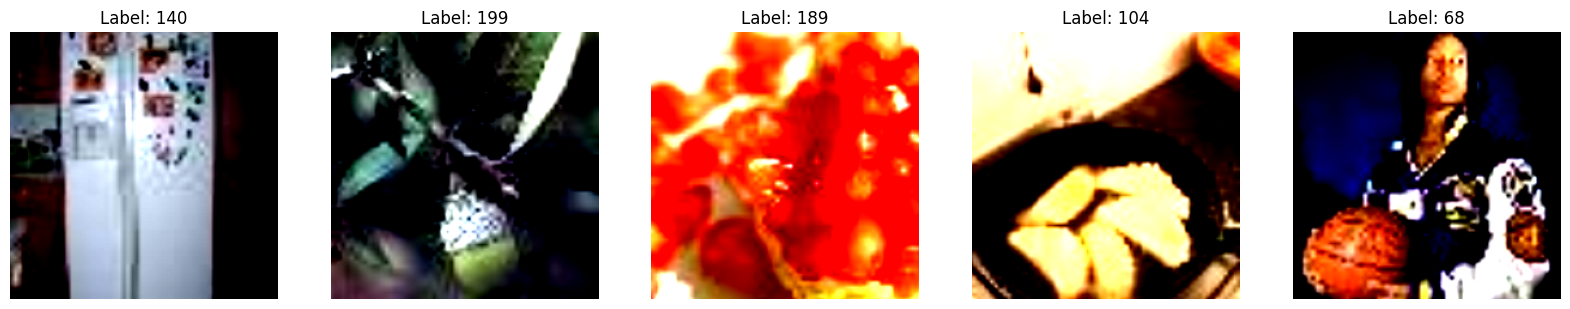

In [9]:
# Plotting the first few images in the batch
images, labels = next(iter(train_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {int(labels[i])}")
plt.show()

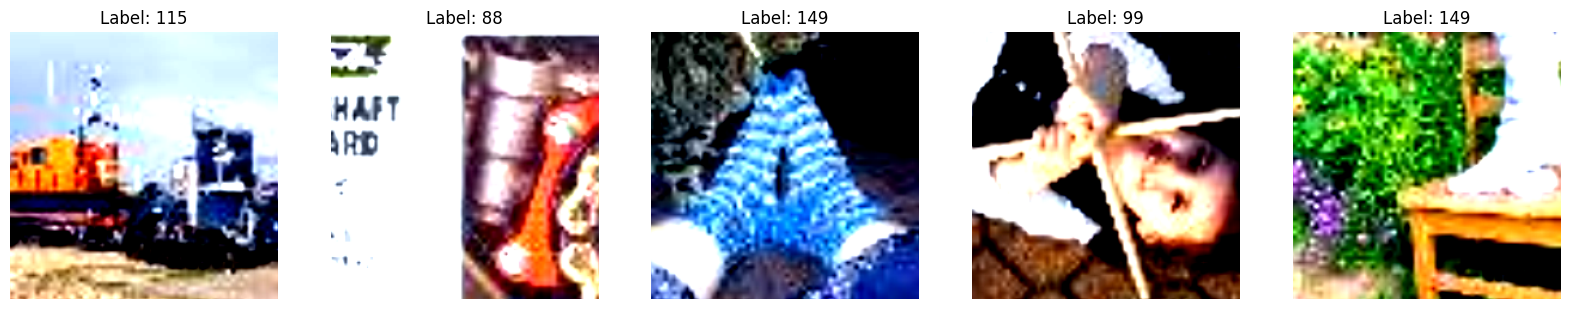

In [10]:
# Plotting the first few images in the batch
images, labels = next(iter(val_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {int(labels[i])}")
plt.show()

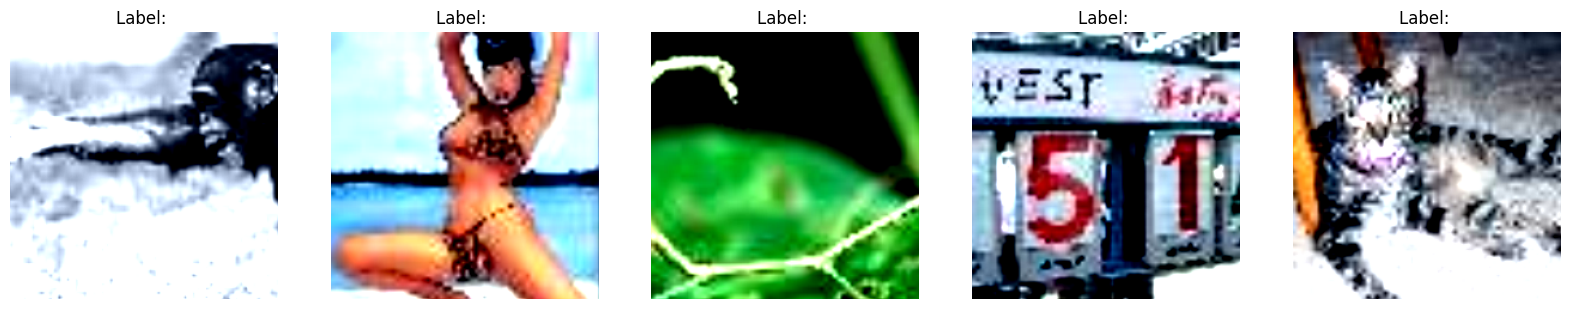

In [11]:
# Plotting the first few images in the batch
images = next(iter(test_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: ")
plt.show()

## Test Set — No Labels Available

 The test set does not include ground-truth labels. To evaluate your model
 on the test set, you need to:

 1. Run inference on the test loader to get predictions for each image
 2. Create a CSV with two columns: `File` (the image filename) and `Encoded_Label` (your predicted class)
 3. Submit that CSV for evaluation

 You can generate it like this:

 ```python
 import torch
 import pandas as pd

 model.eval()
 filenames   = test_dataset.df["File"].tolist()
 predictions = []

 with torch.inference_mode():
     for i, images in enumerate(test_loader):
         images  = images.to(device)
         logits  = model(images)
         preds   = logits.argmax(dim=1).cpu().tolist()
         predictions.extend(preds)

 submission = pd.DataFrame({"File": filenames, "Encoded_Label": predictions})
 submission.to_csv("submission.csv", index=False)
 print(submission.head())
 ```

 Make sure the order of `filenames` matches the order images are loaded
 by the test loader — since `shuffle=False`, the order is preserved.

In [12]:
import torch 
import torchvision
import torchmetrics
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torch.utils.tensorboard import SummaryWriter
from torchvision.models import resnet50, ResNet50_Weights

2026-04-04 00:08:17.646385: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775261297.837109      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775261297.899997      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775261298.380320      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775261298.380363      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775261298.380365      55 computation_placer.cc:177] computation placer alr

In [13]:
# Listar los modelos que contengan la palabra resnet
entrypoints = torch.hub.list('pytorch/vision', force_reload=True)
for modelo in entrypoints:
    if 'resnet' in modelo:
        print(modelo)

Downloading: "https://github.com/pytorch/vision/zipball/main" to /root/.cache/torch/hub/main.zip
deeplabv3_resnet101
deeplabv3_resnet50
fcn_resnet101
fcn_resnet50
resnet101
resnet152
resnet18
resnet34
resnet50
wide_resnet101_2
wide_resnet50_2


In [14]:
# Cargar el modelo, el modelo solo posee una configuración de pesos
modelo = torch.hub.load('pytorch/vision:v0.13.0', 'resnet50', weights = 'IMAGENET1K_V1')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Downloading: "https://github.com/pytorch/vision/zipball/v0.13.0" to /root/.cache/torch/hub/v0.13.0.zip
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 201MB/s] 


In [15]:
# Congelar los parametros de la parte que extrae las caracteristicas
for parametro in modelo.parameters():
    parametro.requires_grad = False

# Editar la ultima capa
modelo.fc = nn.Linear(2048, 200)
# print(modelo)

In [16]:
def train_one_epoch(model, loader, optimizer, criterion, acc_metric, device):
    model.train()
    acc_metric.reset()
    total_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        acc_metric.update(logits, labels)

    return total_loss / len(loader.dataset), acc_metric.compute().item()


def evaluate(model, loader, criterion, acc_metric, device):
    model.eval()
    acc_metric.reset()
    total_loss = 0.0

    with torch.inference_mode():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            total_loss += criterion(logits, labels).item() * labels.size(0)
            acc_metric.update(logits, labels)

    return total_loss / len(loader.dataset), acc_metric.compute().item()


In [17]:
model = modelo.to(device)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr = 1e-3)
criterion = nn.CrossEntropyLoss()
train_acc = torchmetrics.Accuracy(task = 'multiclass', num_classes = 200).to(device)
val_acc = torchmetrics.Accuracy(task = 'multiclass', num_classes = 200).to(device)
writer = SummaryWriter(log_dir = 'logs/modelo_2etapas')

In [18]:
etapa_1 = 5
print("--- Stage 1: FC only ---")

for epoch in range(1, etapa_1 + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, train_acc, device)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, val_acc, device)
    writer.add_scalars('loss', {'train': tr_loss,'val': vl_loss}, epoch)
    writer.add_scalars('Accuracy', {'train': tr_acc, 'val': vl_acc}, epoch)
    writer.add_scalar('Stage', 1, epoch)
    print(
        f'Epoch {epoch:02d}/{etapa_1} | '
        f'Train loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
        f'Val loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}'
    )

--- Stage 1: FC only ---
Epoch 01/5 | Train loss: 2.1420 Acc: 0.5092 | Val loss: 1.7019  Acc: 0.5875
Epoch 02/5 | Train loss: 1.6667 Acc: 0.5923 | Val loss: 1.7128  Acc: 0.5882
Epoch 03/5 | Train loss: 1.6048 Acc: 0.6071 | Val loss: 1.6593  Acc: 0.6127
Epoch 04/5 | Train loss: 1.5644 Acc: 0.6170 | Val loss: 1.6401  Acc: 0.6147
Epoch 05/5 | Train loss: 1.5356 Acc: 0.6241 | Val loss: 1.6643  Acc: 0.6087


In [19]:
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr = 1e-4)
etapa_2 = 45
total_etapas = etapa_1 + etapa_2

In [ ]:
print("\n--- Stage 2: Full fine-tuning ---")
for epoch in range(etapa_1 + 1, total_etapas + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, train_acc, device)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, val_acc, device)
    writer.add_scalars('Loss', {'train': tr_loss, 'val': vl_loss}, epoch)
    writer.add_scalars('Accuracy', {'train': tr_acc, 'val': vl_acc}, epoch)
    writer.add_scalar('Stage', 2, epoch)

    print(f"Epoch {epoch:02d}/{total_etapas} | "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")
writer.close()


--- Stage 2: Full fine-tuning ---
Epoch 06/50 | Train Loss: 1.0857  Acc: 0.7134 | Val Loss: 1.0361  Acc: 0.7253
Epoch 07/50 | Train Loss: 0.7810  Acc: 0.7828 | Val Loss: 1.0478  Acc: 0.7418
Epoch 08/50 | Train Loss: 0.6203  Acc: 0.8219 | Val Loss: 1.1117  Acc: 0.7253


In [ ]:
test_acc = torchmetrics.Accuracy(task="multiclass", num_classes=200).to(device)
te_loss, te_acc = evaluate(model, test_loader, criterion, test_acc, device)
print(f"\nTest Loss: {te_loss:.4f} | Test Accuracy: {te_acc:.4f}")